# Electricity Consumption Data Analysis
# Energy Data Analysis / Enerji Verisi Analizi

### English
This project analyzes hourly electricity consumption data using Python and Pandas.

## Objective
The main objective is to explore electricity demand patterns across time and identify trends, seasonality, weekday/weekend differences, and peak-demand periods.

---

### Türkçe
Bu proje, Python ve Pandas kütüphanelerini kullanarak saatlik elektrik tüketim verilerini analiz etmektedir.

## Amaç
Temel amaç, zaman içindeki elektrik talebi modellerini keşfetmek; eğilimleri, mevsimselliği, hafta içi/hafta sonu farklarını ve pik talep dönemlerini belirlemektir.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import datetime
%matplotlib inline

In [ ]:
df = pd.read_csv("AEP_hourly.csv")

In [ ]:
df.head(3)

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  object 
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB


In [ ]:
df.describe()

,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


In [ ]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

df["New_Date"] = df["Datetime"].dt.date

df["New_Time"] = df["Datetime"].dt.time

In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  121273 non-null  datetime64[ns]
 1   AEP_MW    121273 non-null  float64       
 2   New_Date  121273 non-null  object        
 3   New_Time  121273 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 3.7+ MB


In [ ]:
df["Year"] = df["Datetime"].dt.year

In [ ]:
df[["Datetime", "Year"]].head()

,Datetime,Year
0,2004-12-31 01:00:00,2004
1,2004-12-31 02:00:00,2004
2,2004-12-31 03:00:00,2004
3,2004-12-31 04:00:00,2004
4,2004-12-31 05:00:00,2004


### Veri Seti İncelemesi / Dataset Overview

**Türkçe:**
Şu ana kadar AEP (American Electric Power) saatlik güç tüketimi veri setini yükledik ve genel yapısını inceledik. Tarih ve saat bilgilerini (`Datetime`) daha rahat analiz edebilmek için tarih, saat ve yıl bazında yeni sütunlara ayırdık.

**English:**
So far, we have loaded the AEP (American Electric Power) hourly energy consumption dataset and explored its general structure. We successfully parsed the `Datetime` column into separate date, time, and year columns to facilitate our analysis.

### Yıllık Tüketim Analizi / Annual Consumption Analysis

**Türkçe:**
Bu bölümde, her bir yıl için kaç saatlik elektrik tüketim verisi bulunduğunu (kayıt sayısını) ve o yılın ortalama tüketim değerini (`AEP_MW` ortalaması) inceleyeceğiz. Bu analiz, veri kümesinde eksik veri olup olmadığını anlamamıza ve yıllar içindeki genel enerji talebi trendlerini gözlemlememize yardımcı olacaktır.

**English:**
In this section, we will analyze the total number of hourly electricity consumption records and the average consumption value (`AEP_MW` average) for each year. This analysis will help us identify any missing periods in our dataset and observe the overall energy demand trends across the years.

In [ ]:
yearly_analysis = df.groupby("Year")["AEP_MW"].agg(["count", "mean"])
yearly_analysis

,count,mean
Year,,
2004,2206,15176.724388
2005,8758,15842.990865
2006,8758,15737.224252
2007,8758,16645.519297
2008,8782,16536.655659
2009,8758,15254.111669
2010,8757,16008.619504
2011,8758,15815.389472
2012,8781,15352.940667


<Axes: xlabel='Year'>

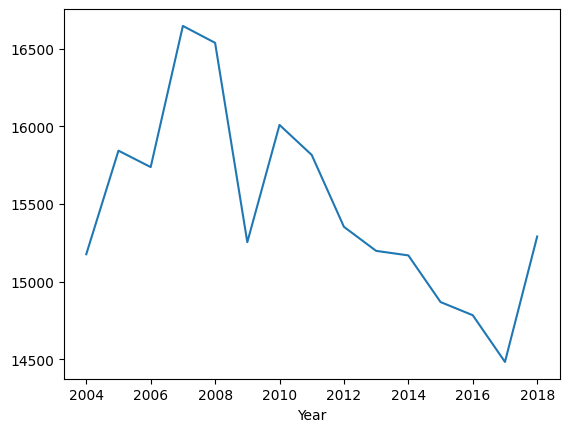

In [ ]:
yearly_analysis["mean"].plot(kind = "line")

### Yıllık Ekstrem Tüketim Analizi / Annual Extreme Consumption Analysis

**Türkçe:**
Yıllık ortalama tüketim bize genel eğilimi gösterse de, enerji yönetiminde en kritik noktalardan biri de karşılaşılan en yüksek (maksimum) ve en düşük (minimum) tüketim seviyeleridir. Bu değerler, şebekenin pik yük kapasitelerini ve mevsimsel dalgalanmaların boyutunu anlamamıza yardımcı olur. Şimdi her bir yıl için minimum, maksimum ve ortalama tüketim değerlerini birlikte inceleyelim.

**English:**
While the annual average consumption shows us the general trend, some of the most critical aspects of energy management are the highest (maximum) and lowest (minimum) consumption levels. These values help us understand peak load capacities of the grid and the magnitude of seasonal fluctuations. Let's analyze the minimum, maximum, and average consumption values together for each year.

In [ ]:
yearly_analysis = df.groupby("Year")["AEP_MW"].agg(["count", "min", "mean", "max"])
display(yearly_analysis)

,count,min,mean,max
Year,,,,
2004,2206,10263.0,15176.724388,22577.0
2005,8758,9823.0,15842.990865,24015.0
2006,8758,10176.0,15737.224252,24842.0
2007,8758,10858.0,16645.519297,25164.0
2008,8782,11021.0,16536.655659,25695.0
2009,8758,9701.0,15254.111669,24703.0
2010,8757,10070.0,16008.619504,23736.0
2011,8758,10479.0,15815.389472,24597.0
2012,8781,9669.0,15352.940667,23320.0


### Aylık Tüketim Analizi / Monthly Consumption Analysis

**Türkçe:**
Yıllık analizle genel tüketim seviyesini inceledik. Şimdi aylık tüketim davranışına geçelim. Bu aşamada şu soruya cevap arayacağız:

*Elektrik tüketimi yılın hangi aylarında daha yüksek veya daha düşük?*

**English:**
We have analyzed the overall consumption level with the annual analysis. Now let's move on to monthly consumption behavior. In this stage, we will seek an answer to the following question:

*In which months of the year is electricity consumption higher or lower?*

In [ ]:
df["Month"] = df["Datetime"].dt.month

monthly_analysis = df.groupby("Month")["AEP_MW"].mean()
monthly_analysis

,AEP_MW
Month,
1,17431.269009
2,17022.815084
3,15376.835720
4,13823.857511
5,14006.393817
6,15630.021825
7,16349.853303
8,16424.881699
9,14657.280556


### Aylık Tüketimde Mevsimsellik ve Analist Yaklaşımı / Seasonality in Monthly Consumption and Analyst Perspective

**Türkçe:**
* **Kış → Yüksek Tüketim**
* **İlkbahar → Düşüş**
* **Yaz → Tekrar Yükseliş**
* **Sonbahar → Tekrar Düşüş**
* **Aralık → Yeniden Yükseliş**

Bu döngü, veri setinde güçlü bir **seasonality (mevsimsellik)** olduğunu açıkça düşündürüyor.

Fakat burada önemli bir analist refleksini devreye sokmalıyız: Henüz "Ocak ayında insanlar kesin olarak daha fazla elektrik tüketiyor" gibi kesin neden-sonuç ilişkileri kurmamalıyız. Çünkü bu değerlerin arkasında hava sıcaklığı, ısıtma/soğutma ihtiyaçları, ekonomik faaliyetler veya sanayi yükü gibi birçok farklı dışsal faktör olabilir. Biz şu anda yalnızca verideki paterni (kalıbı) tespit ediyoruz.

Şimdi bu paterni daha net görebilmek için görselleştirelim. Aylar sıralı bir zaman döngüsünü temsil ettiği için bu aşamada bir **çizgi grafik (line chart)** kullanmak oldukça mantıklı olacaktır.

---

**English:**
* **Winter → High Consumption**
* **Spring → Decrease**
* **Summer → Rise Again**
* **Autumn → Decrease Again**
* **December → Rise Again**

This cycle clearly suggests a strong **seasonality** in the dataset.

However, we should apply a key analyst reflex here: we should not yet conclude with absolute certainty that "people definitely consume more electricity in January." This is because behind these values, there could be many external factors such as air temperature, heating/cooling demands, economic activities, or industrial loads. At this stage, we are simply detecting the pattern in the data.

Let's visualize this pattern to see it more clearly. Since months represent a sequential time cycle, using a **line chart** is highly appropriate for this step.

<Axes: xlabel='Month'>

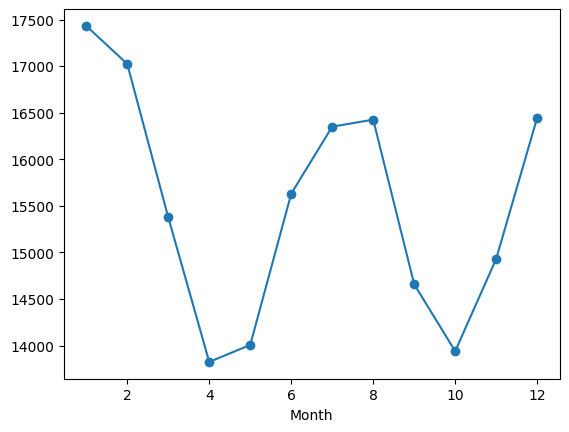

In [ ]:
monthly_analysis.plot(kind="line", marker="o")

### Gün İçi (Saatlik) Tüketim Analizi / Intraday (Hourly) Consumption Analysis

**Türkçe:**
Gün içindeki saatlere göre tüketim davranışını da analiz edelim. Bu analizde özellikle şu sorulara dikkat edeceğiz:

* **Gece saatlerinde tüketim nasıl?**
* **Sabah saatlerinde bir yükseliş var mı?**
* **Öğle saatlerinde ne oluyor?**
* **Akşam saatlerinde peak (zirve) oluşuyor mu?**
* **En düşük ve en yüksek saatler yaklaşık hangileri?**

**English:**
Let's also analyze consumption behavior based on hours of the day. In this analysis, we will focus on the following questions in particular:

* **How is the consumption during the night hours?**
* **Is there a rise during the morning hours?**
* **What happens during midday?**
* **Does a peak occur during the evening hours?**
* **Which are approximately the lowest and highest hours?**

In [ ]:
df["Hour"] = df["Datetime"].dt.hour
hourly_analysis = df.groupby("Hour")["AEP_MW"].mean()
hourly_analysis

,AEP_MW
Hour,
0,14651.191569
1,13891.478433
2,13432.062995
3,13184.049008
4,13095.193350
5,13240.535813
6,13802.401464
7,14781.668381
8,15478.830233


### Saatlik Tüketim Görselleştirmesi ve Uç Değer Analizi / Hourly Consumption Visualization and Extreme Value Analysis

**Türkçe:**
Saatlik ortalamaları artık görsel olarak inceleyelim. Burada çizgi grafik (line chart) kullanmak oldukça uygundur; çünkü saatler sıralı bir düzeni takip eder ve saatler arasındaki geçiş/değişim eğilimi bizim için önemlidir.

Bu grafiği inceledikten sonra bir sonraki adımda veri setindeki **gerçek maksimum tüketim kaydını** bulup şu soruları cevaplayacağız:
* **Hangi tarihte gerçekleşmiş?**
* **Hangi saatte gerçekleşmiş?**
* **Kaç MW tüketim gerçekleşmiş?**

---

**English:**
Let's now analyze the hourly averages visually. A line chart is highly appropriate here because hours follow a sequential order and the trend of change between hours is key to our understanding.

After examining this plot, in the next step, we will locate the **actual maximum consumption record** in the dataset and answer the following questions:
* **On which date did it occur?**
* **At what hour did it occur?**
* **How many MWs of consumption was reached?**

<Axes: xlabel='Hour'>

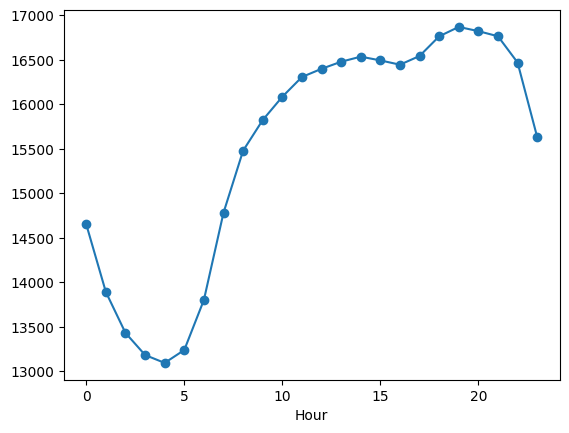

In [ ]:
hourly_analysis.plot(kind="line", marker="o")

### En Yüksek (Pik) Talep Analizi / Peak Demand Analysis

**Türkçe:**
Şimdi ortalama saatlik davranıştan gerçek **peak demand** (pik talep / zirve talep) analizine geçiyoruz. (Notebook'u inceleyen kişi/kişiler, bu kavramın anlamını bilmiyorsa araştırmalıdır.)

Bu aşamada şu kritik sorunun cevabını arayacağız:
*"Veri setindeki tek bir saatte gerçekleşen en yüksek tüketim ne zaman ve kaç MW?"*

**English:**
Now, we are transitioning from the average hourly behavior to the actual **peak demand** analysis. (Anyone reviewing this notebook who is unfamiliar with this concept should research it.)

In this stage, we will seek the answer to this critical question:
*"When did the single highest hourly consumption occur in the dataset, and how many MW was it?"*

In [ ]:
peak_demand = df.sort_values("AEP_MW", ascending=False)
peak_demand[["Datetime", "AEP_MW"]].head(10)

,Datetime,AEP_MW
30221,2008-10-20 14:00:00,25695.0
23216,2007-08-08 15:00:00,25164.0
23218,2007-08-08 17:00:00,25140.0
23217,2007-08-08 16:00:00,25056.0
23194,2007-08-09 17:00:00,25035.0
23193,2007-08-09 16:00:00,24978.0
23215,2007-08-08 14:00:00,24941.0
23192,2007-08-09 15:00:00,24911.0
23219,2007-08-08 18:00:00,24878.0
22858,2007-08-23 17:00:00,24862.0


### Yıllık En Yüksek (Pik) Talep Analizi / Annual Peak Demand Analysis

**Türkçe:**
Az önceki sonuç bize tüm veri kümesindeki "en yüksek 10 saat"i verdi. Şimdi analizi daha sistematik hale getirelim ve daha anlamlı bir soru soralım:

*Her yılın kendi peak demand (en yüksek tüketim) değeri nedir?*

Böylece 2004–2018 yılları arasında yıllık maksimum tüketimin nasıl bir değişim gösterdiğini gözlemleyebiliriz.

---

**English:**
The previous result showed us the "top 10 highest hours" across the entire dataset. Let's make this analysis more systematic and ask a more meaningful question:

*What is the peak demand (maximum consumption) value for each individual year?*

This will allow us to observe how the annual maximum consumption has evolved between 2004 and 2018.

In [ ]:
yearly_peak = df.groupby("Year")["AEP_MW"].max()
yearly_peak

,AEP_MW
Year,
2004,22577.0
2005,24015.0
2006,24842.0
2007,25164.0
2008,25695.0
2009,24703.0
2010,23736.0
2011,24597.0
2012,23320.0


<Axes: xlabel='Year'>

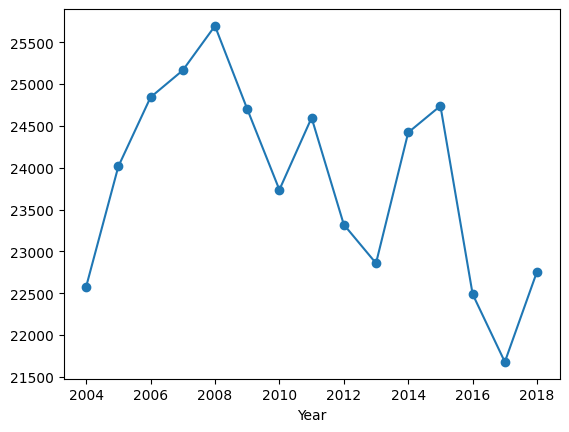

In [ ]:
yearly_peak.plot(kind="line", marker="o")

**Türkçe:**
Şimdi weekday / weekend davranışını inceleyelim. Bu, enerji tüketiminde günlük rutinlerin etkisini görmek açısından önemli.
Hafta içi günler birbirine yakın mı?
Cumartesi ve pazar hafta içine göre nasıl?
En yüksek ortalama hangi gün?
En düşük hangi gün?
Hafta sonunun belirgin şekilde farklı olup olmadığını söyleyebilir miyiz?

---

**English:**
Now let's analyze weekday / weekend behavior. This is important to see the impact of daily routines on energy consumption.
Are weekdays close to each other?
How do Saturday and Sunday compare to weekdays?
Which day has the highest average?
Which day has the lowest?
Can we say whether the weekend is significantly different?

In [ ]:
df["DayOfWeek"] = df["Datetime"].dt.dayofweek
daily_analysis = df.groupby("DayOfWeek")["AEP_MW"].mean()
daily_analysis

,AEP_MW
DayOfWeek,
0,15810.973684
1,16057.615571
2,16013.589739
3,16028.138281
4,15773.123911
5,14610.979628
6,14200.754680


**Türkçe:**
Hafta içi tüketim profili oldukça stabilken, hafta sonu özellikle pazar günü belirgin bir talep düşüşü görülüyor. Görsel olarak çok daha net hale getirelim. Grafik burada kategorik karşılaştırma olduğu için bar chart daha uygun.

---

**English:**
While the weekday consumption profile is quite stable, a significant drop in demand is observed during the weekend, especially on Sunday. Let's make this much clearer visually. Since the plot represents a categorical comparison, a bar chart is more appropriate.

<Axes: xlabel='DayOfWeek'>

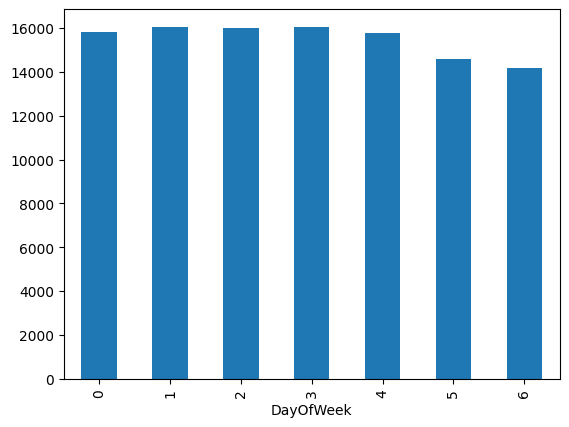

In [ ]:
daily_analysis.plot(kind="bar")

**Türkçe:**
Aynı analizi bir üst seviyeye taşıyalım: tek tek günleri değil, hafta içi ve hafta sonunu karşılaştıracağız.

---

**English:**
Let's take the same analysis to the next level: instead of individual days, we will compare weekdays and weekends directly.

In [ ]:
df["DayType"] = df["DayOfWeek"].apply(
    lambda x: "Weekday" if x < 5 else "Weekend"
)

In [ ]:
daytype_analysis = df.groupby("DayType")["AEP_MW"].mean()
daytype_analysis

,AEP_MW
DayType,
Weekday,15936.687674
Weekend,14405.985593


**Türkçe:**
Ardından şunu düşünelim:

Hafta sonu ortalama tüketimi, hafta içine göre yüzde kaç daha düşük?

---

**English:**
Next, let's consider this:

By what percentage is the average weekend consumption lower than that of the weekdays?

In [ ]:
(
    (daytype_analysis["Weekday"] - daytype_analysis["Weekend"])
    / daytype_analysis["Weekday"]
) * 100

np.float64(9.604894769594699)

**Türkçe:**
Şimdi mevsimsellik (seasonality) analizine geçelim. Bu, önceki aylık analizimizin doğal devamı.
Burada ne arıyoruz?

Önceki aylık analizimizden zaten bir beklentimiz var:

* Kış ayları yüksek
* İlkbahar düşük
* Yaz tekrar yükseliyor
* Sonbahar tekrar düşüyor

Ama şimdi bunu 4 temel mevsimsel profile indirgemiş oluyoruz.

---

**English:**
Now let's move on to seasonality analysis. This is a natural continuation of our previous monthly analysis.
What are we looking for here?

We already have an expectation from our previous monthly analysis:

* Winter months are high
* Spring is low
* Summer rises again
* Autumn drops again

But now, we are condensing this into 4 core seasonal profiles.

In [ ]:
df["Season"] = df["Month"].apply(
    lambda x:
        "Winter" if x in [12, 1, 2]
        else "Spring" if x in [3, 4, 5]
        else "Summer" if x in [6, 7, 8]
        else "Autumn"
)

In [ ]:
df[["Month", "Season"]].head(10)

,Month,Season
0,12,Winter
1,12,Winter
2,12,Winter
3,12,Winter
4,12,Winter
5,12,Winter
6,12,Winter
7,12,Winter
8,12,Winter
9,12,Winter


In [ ]:
seasonal_analysis = df.groupby("Season")["AEP_MW"].mean()

In [ ]:
season_order = ["Winter", "Spring", "Summer", "Autumn"]

seasonal_analysis = seasonal_analysis.reindex(season_order)
seasonal_analysis

,AEP_MW
Season,
Winter,16964.861696
Spring,14408.280933
Summer,16133.863951
Autumn,14498.909377


<Axes: xlabel='Season'>

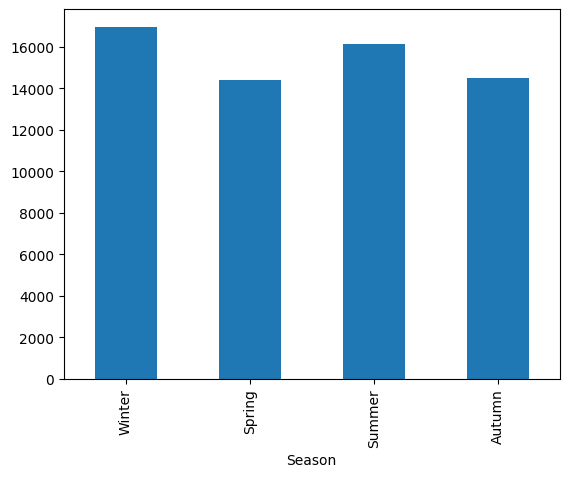

In [ ]:
seasonal_analysis.plot(kind="bar")

**Türkçe:**
Trend ile mevsimselliği aynı anda düşünelim.

Şu ana kadar:

* **Year** → uzun vadeli değişim
* **Month** → yıl içindeki tekrar eden davranış
* **Hour** → gün içindeki tekrar eden davranış
* **DayOfWeek** → haftalık davranış
* **Season** → mevsimsel davranış

inceledik.

Şimdi bunları daha gerçekçi bir zaman serisi görünümünde birleştirelim.

---

**English:**
Let's consider trend and seasonality together.

So far, we have analyzed:

* **Year** → long-term change
* **Month** → repeating behavior within the year
* **Hour** → repeating behavior within the day
* **DayOfWeek** → weekly behavior
* **Season** → seasonal behavior

Now, let's combine these into a more realistic time series view.

<Axes: xlabel='Datetime'>

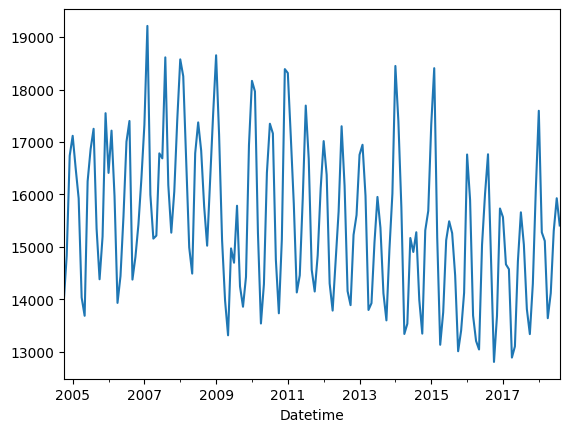

In [ ]:
monthly_trend = df.set_index("Datetime")["AEP_MW"].resample("ME").mean()
monthly_trend.plot(kind="line")

**Türkçe:**
İstatistik tarafında biraz daha derinlere iniyoruz. Şimdi rolling average (hareketli ortalama) kullanacağız. Bu, zaman serisi analizinde çok temel ve ileride forecasting tarafında da işimize yarayacak bir teknik. Rolling average bize:

"Mevsimsel dalgalanmaları tamamen yok etmeden, genel seviyenin zaman içinde nereye gittiğini daha rahat görebilir miyim?"

sorusunun cevabını verir.

---

**English:**
We are diving a bit deeper into the statistical side. Now we will use a rolling average (moving average). This is a very fundamental technique in time series analysis that will also be useful for us in forecasting later on. A rolling average answers this question:

"Can I more easily see where the general level is heading over time, without completely eliminating seasonal fluctuations?"

<Axes: xlabel='Datetime'>

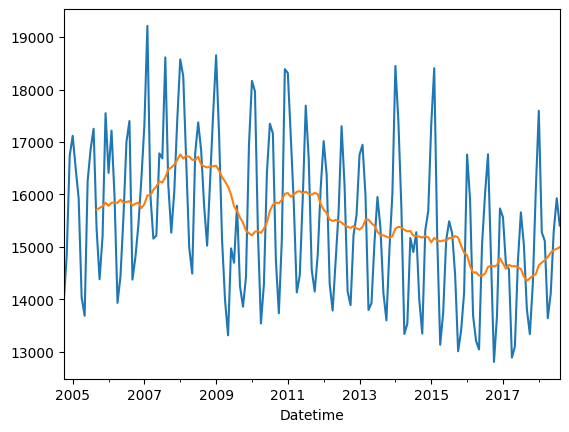

In [ ]:
rolling_12m = monthly_trend.rolling(window=12).mean()
monthly_trend.plot(kind="line")
rolling_12m.plot(kind="line")

**Türkçe:**
Devam edelim. Şimdi dağılım ve aykırı değerler (outlier) tarafına geçiyoruz.

Peak analizinde 25,695 MW değerinin veri içerisindeki en yüksek gözlem olduğunu gördük. Şimdi bunun genel tüketim dağılımında ne kadar sıra dışı olduğunu inceleyeceğiz.

---

**English:**
Let's continue. Now we are moving on to the distribution and outlier analysis side.

In our peak analysis, we saw that the value of 25,695 MW was the highest observation in the dataset. Now, we will examine how unusual this is within the overall distribution of consumption.

<Axes: ylabel='Frequency'>

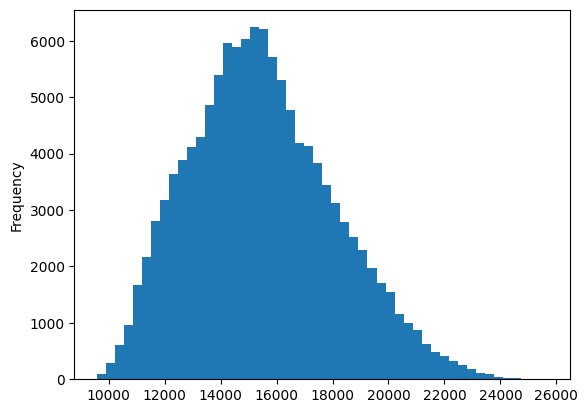

In [ ]:
df["AEP_MW"].plot(kind="hist", bins=50)

**Türkçe:**
Burada amacımız tek tek değerleri değil, tüketimin hangi MW aralıklarında yoğunlaştığını görmek.

Şunlara dikkat et:

* Veriler tek bir bölgede mi yoğunlaşıyor?
* Dağılım simetrik mi?
* Çok yüksek değerlere doğru uzun bir kuyruk var mı?
* Birden fazla tepe (peak) görüyor musun?

---

**English:**
Our goal here is not to look at individual values, but to see in which MW ranges the consumption is concentrated.

Pay attention to these:

* Is the data concentrated in a single region?
* Is the distribution symmetrical?
* Is there a long tail extending towards very high values?
* Do you see multiple peaks?

**Türkçe:**
Şimdi aynı dağılımı başka bir açıdan görelim, burada özellikle:

* Median
* Q1 / Q3
* IQR
* Whisker'lar
* Outlier noktaları

arasındaki ilişkiyi düşün.

---

**English:**
Now let's see the same distribution from another perspective, and consider the relationships between especially these:

* Median
* Q1 / Q3
* IQR
* Whiskers
* Outlier points

<Axes: >

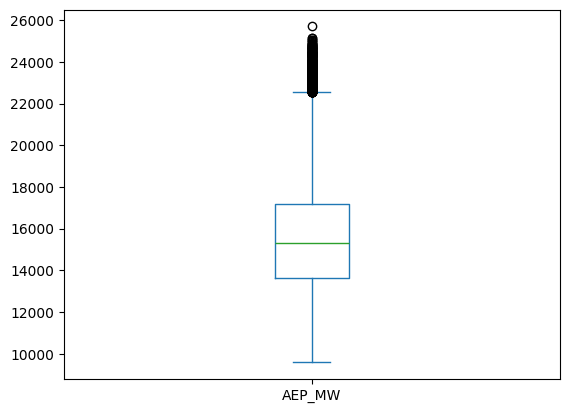

In [ ]:
df["AEP_MW"].plot(kind="box")

**Türkçe:**
NOT: Outlier = hatalı veri demek değildir.

Enerji tüketiminde çok yüksek bir değer gerçekten yaşanmış yüksek talep olabilir.
Dolayısıyla veri analizinde "Outlier'sa silelim." gibi otomatik bir yaklaşım doğru değil.

Önce "Bu değer neden sıra dışı?" diye sorarız.

---

**English:**
NOTE: Outlier does not equal erroneous data.

A very high value in energy consumption could represent a genuinely occurred high demand.
Therefore, an automatic approach like "let's delete it if it's an outlier" is not correct in data analysis.

First, we ask "Why is this value unusual?"

**Türkçe:**
Dağılımı iki açıdan da gördük. İstatistiksel olarak sınırları hesaplayalım. IQR yöntemini kendimiz uygulayalım ve kaç gözlemin bu sınırların dışında olduğunu bulalım.

---

**English:**
We have seen the distribution from both perspectives. Now, let's calculate the limits statistically. Let's apply the IQR method ourselves and find out how many observations lie outside of these boundaries.

In [ ]:
Q1 = df["AEP_MW"].quantile(0.25)
Q3 = df["AEP_MW"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(8275.0), np.float64(22555.0))

In [ ]:
outliers = df[
    (df["AEP_MW"] < lower_bound) |
    (df["AEP_MW"] > upper_bound)
]

len(outliers)

667

**Türkçe:**
NOT: IQR yöntemi sana istatistiksel olarak sıra dışı gözlemleri bulur; peak-demand analizi ise iş açısından önemli ekstrem değerleri bulur.

---

**English:**
NOTE: The IQR method finds statistically unusual observations for you, whereas peak-demand analysis finds business-critical extreme values.

In [ ]:
outliers[["Datetime", "AEP_MW"]].sort_values(
    "AEP_MW",
    ascending=False
).head(10)

,Datetime,AEP_MW
30221,2008-10-20 14:00:00,25695.0
23216,2007-08-08 15:00:00,25164.0
23218,2007-08-08 17:00:00,25140.0
23217,2007-08-08 16:00:00,25056.0
23194,2007-08-09 17:00:00,25035.0
23193,2007-08-09 16:00:00,24978.0
23215,2007-08-08 14:00:00,24941.0
23192,2007-08-09 15:00:00,24911.0
23219,2007-08-08 18:00:00,24878.0
22858,2007-08-23 17:00:00,24862.0


## Technical Summary / Teknik Özet

### English
In this project, hourly electricity consumption data was analyzed using Python and Pandas. The main objective was to explore consumption patterns across different time periods and identify important demand characteristics.

#### Data Preparation
- Loaded the electricity consumption dataset from a CSV file using Pandas.
- Inspected the dataset using `head()`, `info()`, and `describe()`.
- Converted the `Datetime` column into Pandas `datetime` format.
- Extracted time-related features such as year, month, hour, day of week, day type, and season.

#### Exploratory Data Analysis
- Calculated yearly average electricity consumption to examine long-term trends.
- Calculated monthly and seasonal averages to identify seasonality.
- Analyzed average consumption by hour to understand daily demand patterns.
- Compared electricity consumption across weekdays and weekends.
- Identified peak-demand periods and examined the highest consumption observations.
- Compared yearly average demand with yearly peak demand.
- Resampled the data into monthly periods to analyze the chronological time series.
- Applied a 12-month rolling average to make the long-term trend easier to observe.
- Examined the distribution of electricity consumption using histograms and boxplots.
- Used the IQR method to identify statistically unusual observations.

#### Main Findings
The dataset showed clear temporal patterns in electricity demand. Average consumption varied significantly across months and seasons, indicating strong seasonality. Consumption was generally higher during weekdays and noticeably lower during weekends, particularly on Sundays.

Long-term analysis showed changes in average demand across the years. The dataset also contained significant peak-demand events, with the highest observed demand reaching **25,695 MW on October 20, 2008 at 14:00**.

The analysis also demonstrated that average demand and peak demand do not necessarily follow the same trend. Therefore, evaluating an electricity system requires looking not only at average consumption but also at extreme demand periods.

Finally, statistically unusual observations were not automatically treated as erroneous data. In an energy context, extreme observations can represent genuine high-demand events and therefore may contain important operational information.

#### Conclusion
This project provided practical experience in performing an end-to-end exploratory analysis of time-series energy data using Python. The analysis covered data preparation, feature engineering, aggregation, temporal analysis, visualization, and interpretation, providing a foundation for more advanced energy analytics and demand forecasting projects.

---

### Türkçe
Bu projede, Python ve Pandas kütüphaneleri kullanılarak saatlik elektrik tüketim verileri analiz edilmiştir. Temel amaç, farklı zaman dilimlerindeki tüketim kalıplarını keşfetmek ve önemli talep özelliklerini belirlemekti.

#### Veri Hazırlama
- Elektrik tüketim veri seti Pandas kullanılarak bir CSV dosyasından yüklendi.
- Veri seti `head()`, `info()` ve `describe()` fonksiyonlarıyla incelendi.
- `Datetime` sütunu Pandas `datetime` formatına dönüştürüldü.
- Yıl, ay, saat, haftanın günü, gün tipi ve mevsim gibi zamana bağlı özellikler türetildi.

#### Açıklayıcı Veri Analizi (EDA)
- Uzun vadeli eğilimleri incelemek için yıllık ortalama elektrik tüketimi hesaplandı.
- Mevsimselliği belirlemek amacıyla aylık ve mevsimsel ortalamalar çıkarıldı.
- Günlük talep modellerini anlamak için saat bazında ortalama tüketim analiz edildi.
- Hafta içi ve hafta sonu elektrik tüketimleri karşılaştırıldı.
- Pik talep dönemleri belirlendi ve en yüksek tüketim gözlemleri incelendi.
- Yıllık ortalama talep ile yıllık pik talep karşılaştırıldı.
- Kronolojik zaman serisini analiz etmek için veriler aylık dönemlere göre yeniden örneklendi (resample).
- Uzun vadeli eğilimi daha rahat gözlemleyebilmek için 12 aylık hareketli ortalama (rolling average) uygulandı.
- Elektrik tüketiminin dağılımı histogram ve kutu grafikleri (boxplot) kullanılarak incelendi.
- İstatistiki olarak sıra dışı gözlemleri belirlemek için IQR (Çeyrekler Açıklığı) yöntemi kullanıldı.

#### Temel Bulgular
Veri seti, elektrik talebinde net zamansal kalıplar gösterdi. Ortalama tüketim, aylara ve mevsimlere göre önemli ölçüde değişiklik göstererek güçlü bir mevsimselliğe işaret etti. Tüketimin genellikle hafta içi günlerinde daha yüksek, hafta sonlarında (özellikle pazar günleri) ise belirgin şekilde daha düşük olduğu görüldü.

Uzun vadeli analizler, yıllar içinde ortalama talepte değişimler olduğunu gösterdi. Veri setinde ayrıca **20 Ekim 2008 saat 14:00'te ulaşılan 25.695 MW**'lık en yüksek tüketim değeri gibi önemli pik talep olayları gözlemlendi.

Analizler ayrıca ortalama talep ile pik talebin her zaman aynı eğilimi izlemediğini gösterdi. Bu nedenle, bir elektrik şebekesini değerlendirirken sadece ortalama tüketime değil, aynı zamanda ekstrem talep dönemlerine de bakılması gerektiği anlaşıldı.

Son olarak, istatistiksel olarak sıra dışı kabul edilen aykırı değerlerin (outliers) otomatik olarak hatalı veri olarak değerlendirilmemesi gerektiği vurgulandı. Enerji sektöründe bu tür ekstrem gözlemler, gerçek yüksek talep olaylarını temsil edebilir ve operasyonel açıdan kritik bilgiler barındırabilir.

#### Sonuç
Bu proje, Python kullanarak zaman serisi enerji verilerinin uçtan uca açıklayıcı analizini yapma konusunda pratik bir deneyim sağlamıştır. Veri hazırlama, özellik mühendisliği, gruplama, zamansal analiz, görselleştirme ve yorumlama adımlarını kapsayarak, daha gelişmiş enerji analitiği ve talep tahmini projeleri için güçlü bir temel oluşturmuştur.